# Обнаружение мошеннических транзакций: EDA и Предобработка

Структура ноутбука:
1) Загрузка и изучение датасета Credit Card Fraud Detection
2) Предварительный анализ -  EDA
3) Выполнение предобработки и подготовка данных для моделирования

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('./data/creditcard.csv')
print(f'Размер датасета до очистки: {df.shape}')

df = df.dropna(subset=['Class'])

df['Class'] = df['Class'].astype(int)

print(f'Размер после удаления NaN: {df.shape}')
print(f'Количество пропусков в Class после очистки: {df['Class'].isnull().sum()}')
df.head()

Размер датасета до очистки: (284807, 31)
Размер после удаления NaN: (284807, 31)
Количество пропусков в Class после очистки: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [21]:
df.isnull().sum().max()

0

Пропусков нет. Все признаки `V1...V28` - главные компоненты, полученные после PCA. Признаки `Time` и `Amount` оставлены в исходном виде. Целевая переменная: `Class` (0 - легитимная, 1 - мошенническая).

In [22]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f'Доля мошенничества: {class_counts[1] / df.shape[0]:.4%}')

Class
0    284315
1       492
Name: count, dtype: int64
Доля мошенничества: 0.1727%


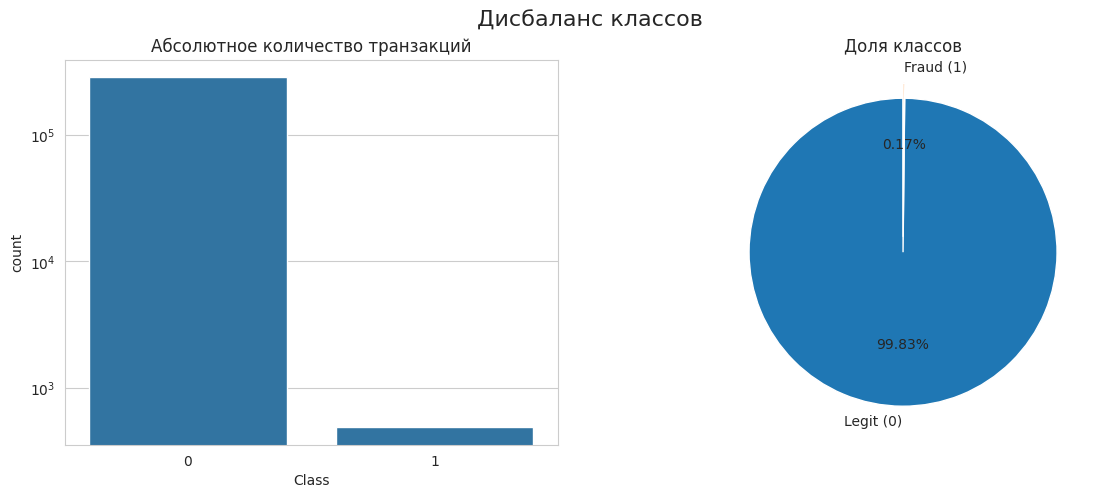

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title('Абсолютное количество транзакций')
ax[0].set_yscale('log')
ax[1].pie(class_counts, labels=['Legit (0)', 'Fraud (1)'], autopct='%1.2f%%', startangle=90, explode=(0, 0.1))
ax[1].set_title('Доля классов')
plt.suptitle('Дисбаланс классов', fontsize=16)
plt.show()

**Вывод:** Всего 492 мошеннических операции на почти 285 тысяч. Доля 0.172% - это экстремально мало, и это напрямую влияет на выбор метрик и методов моделирования.

## Анализ признаков `Time` и `Amount`

In [24]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


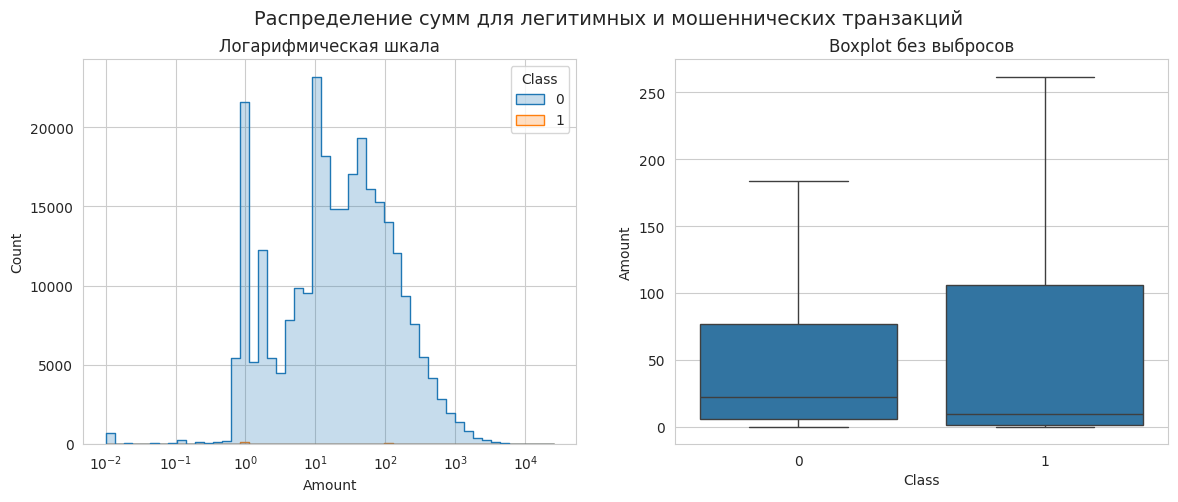

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='Amount', hue='Class', bins=50, log_scale=True, element='step', ax=ax[0])
ax[0].set_title('Логарифмическая шкала')
sns.boxplot(data=df, x='Class', y='Amount', showfliers=False, ax=ax[1])
ax[1].set_title('Boxplot без выбросов')
plt.suptitle('Распределение сумм для легитимных и мошеннических транзакций', fontsize=14)
plt.show()

Средняя сумма мошеннических транзакций чуть выше, но в целом разброс большой. Выбросов много.

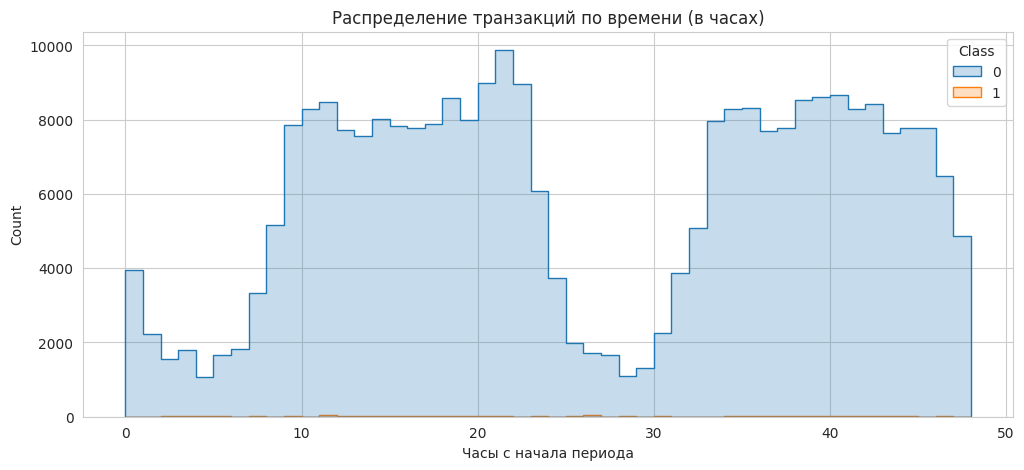

In [26]:
df['Time_hour'] = df['Time'] / 3600

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df, x='Time_hour', hue='Class', bins=48, element='step', ax=ax)
ax.set_title('Распределение транзакций по времени (в часах)')
ax.set_xlabel('Часы с начала периода')
plt.show()

In [27]:
fraud_time = df[df['Class'] == 1]['Time_hour']
legit_time = df[df['Class'] == 0]['Time_hour']
print(f"Среднее время мошеннической транзакции: {fraud_time.mean():.2f} ч")
print(f"Среднее время легитимной транзакции: {legit_time.mean():.2f} ч")

Среднее время мошеннической транзакции: 22.43 ч
Среднее время легитимной транзакции: 26.34 ч


**Вывод:** Видим два крупных всплеска транзакций, возможно, день и вечер. Мошенничество распределено относительно равномерно, без явного часового привязывания. Признак `Time` может нести слабый сигнал, но мы все равно его сохраним и отмасштабируем.

## Анализ PCA-признаков `V1...V28`

In [28]:
df.loc[:, 'V1':'V28'].describe().round(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,...,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000
std,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,...,0.814,0.771,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330
min,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,...,-7.214,-54.498,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430
25%,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,...,-0.456,-0.212,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053
50%,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,...,0.004,-0.062,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011
75%,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,...,0.459,0.133,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078
max,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,...,5.592,39.421,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848


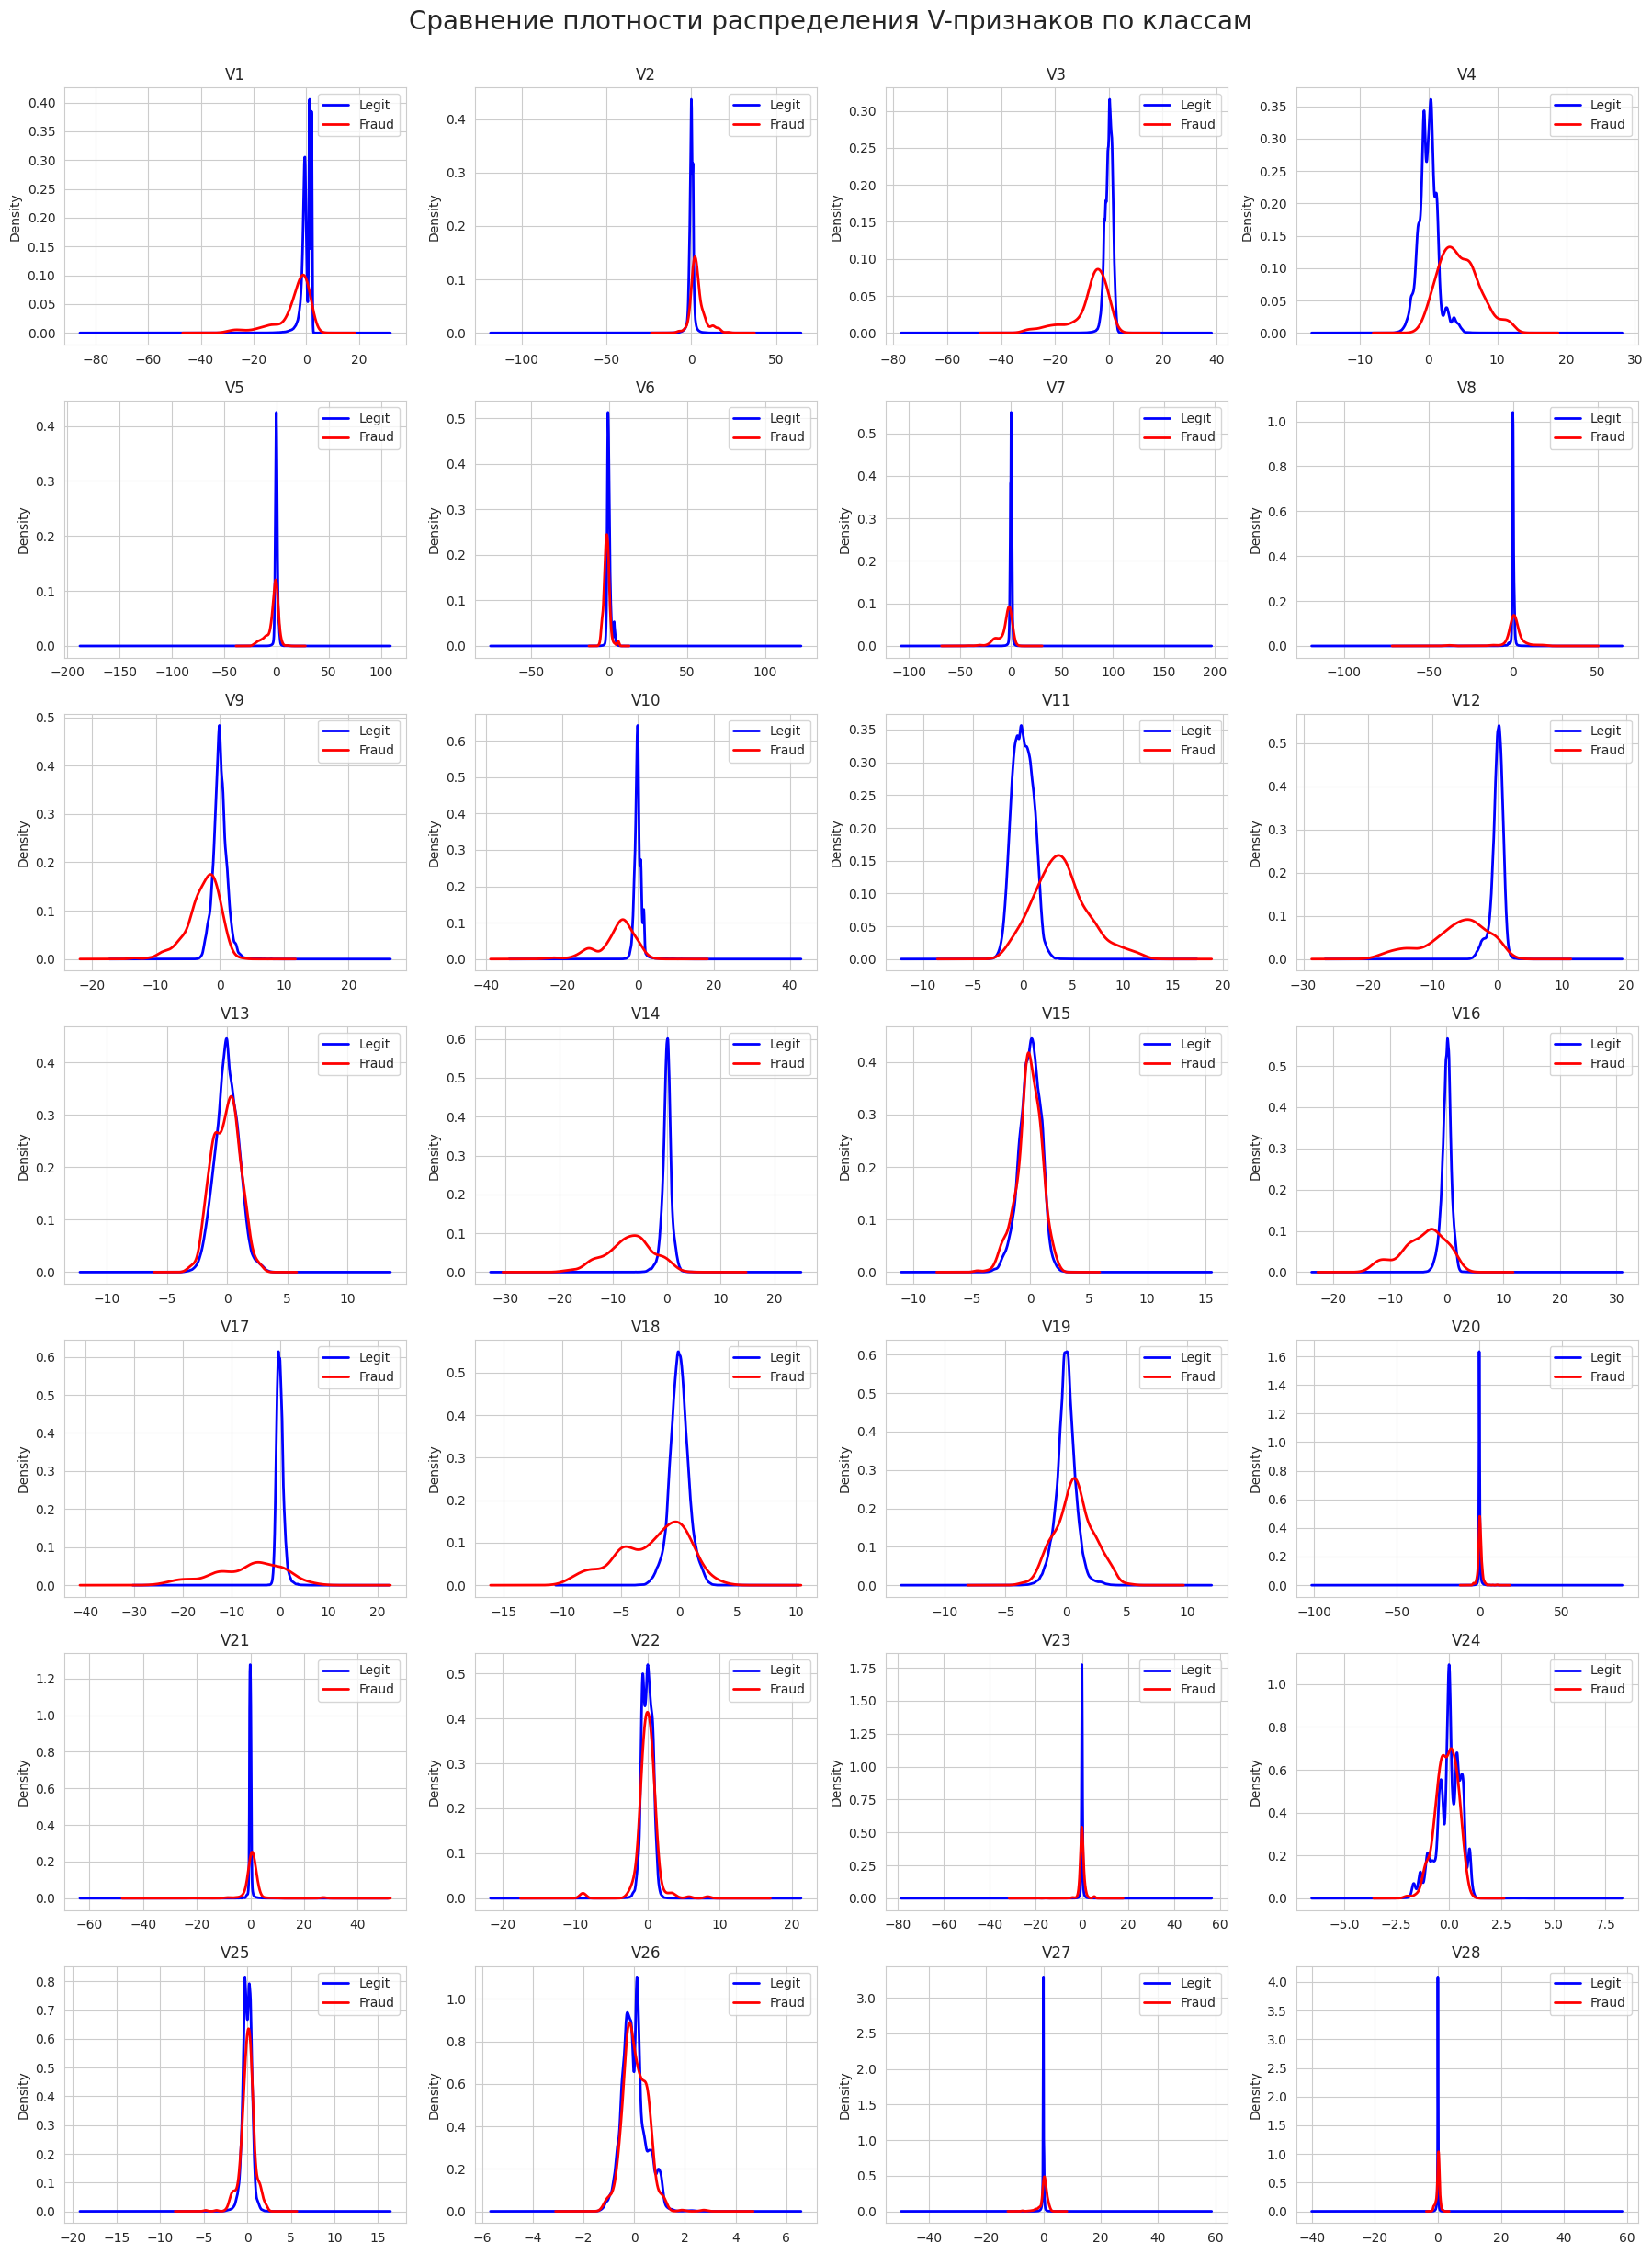

In [29]:
v_features = [f'V{i}' for i in range(1, 29)]
fig, axes = plt.subplots(7, 4, figsize=(18, 24))
axes = axes.flatten()

for i, feature in enumerate(v_features):
    ax = axes[i]
    df[df['Class'] == 0][feature].plot(kind='kde', ax=ax, label='Legit', color='blue', linewidth=2)
    df[df['Class'] == 1][feature].plot(kind='kde', ax=ax, label='Fraud', color='red', linewidth=2)
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.suptitle('Сравнение плотности распределения V-признаков по классам', fontsize=20, y=1.02)
plt.show()

Видим, что многие признаки (V1, V2, V3, V4, V5, V9, V10, V11, V12, V14, V16, V17, V18, V19) демонстрируют отчётливое разделение между классами - пики смещены, значит модель сможет на них опереться. Часть признаков (например, V8, V13, V15, V20-V28) почти не различаются.

## Корреляционный анализ

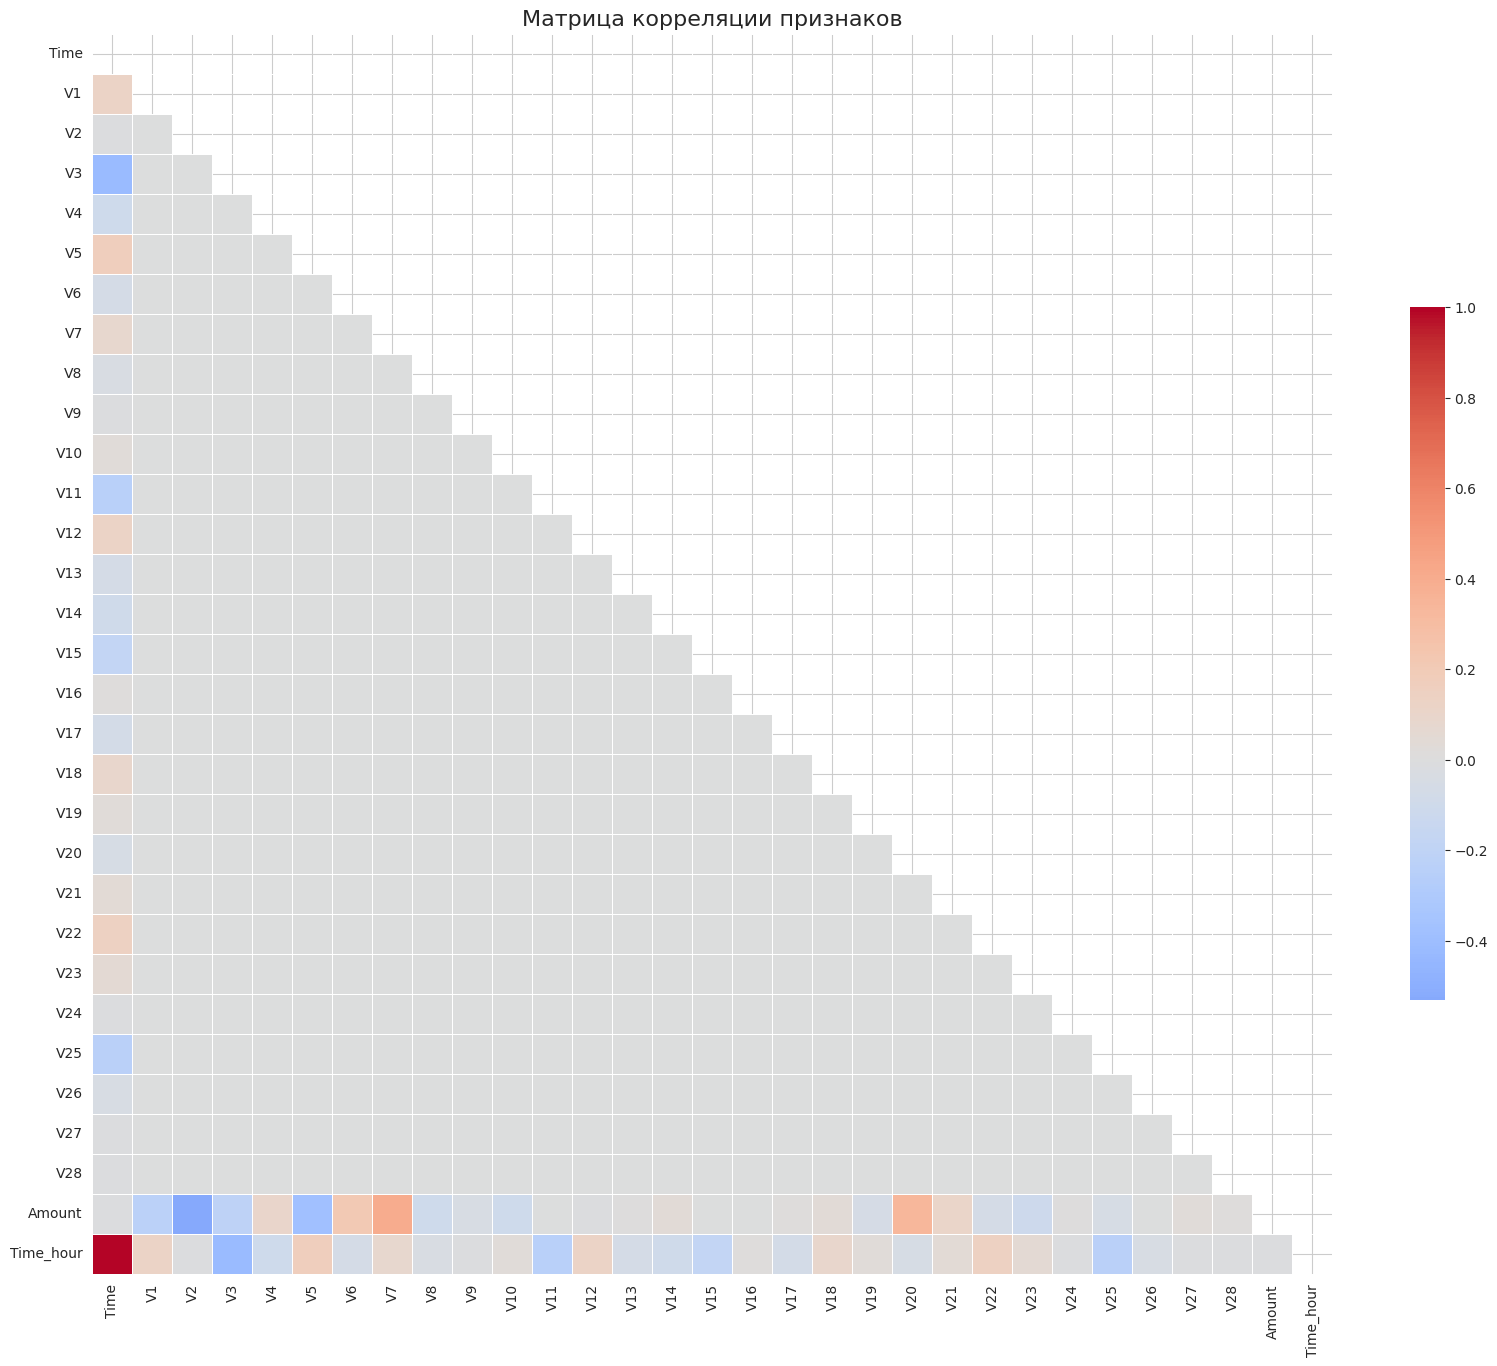

In [30]:
corr = df.drop('Class', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(20, 18))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Матрица корреляции признаков', fontsize=16)
plt.show()

Как и ожидалось после PCA, признаки V1–V28 практически не коррелируют друг с другом. Это упрощает интерпретацию и не требует удаления мультиколлинеарных признаков. Наблюдается небольшая корреляция между Time и V-признаками, но она слабая. Amount выделяется своей шкалой – отмасштабируем его.

## Предобработка данных
1. Масштабирование признака `Amount` с помощью `StandardScaler`.
2. Масштабирование признака `Time`.
3. Удаление вспомогательного столбца `Time_hour`.
4. Разделение на тренировочную и тестовую выборки с учётом стратификации.

In [31]:
df.drop('Time_hour', axis=1, inplace=True)

scaler_amount = StandardScaler()
df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])

scaler_time = StandardScaler()
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])

df.drop(['Amount', 'Time'], axis=1, inplace=True)

print(df.columns.tolist())
df.head()

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [32]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train fraud count: {y_train.sum()}, ratio: {y_train.sum()/len(y_train):.4%}")
print(f"Test fraud count: {y_test.sum()}, ratio: {y_test.sum()/len(y_test):.4%}")

Train shape: (227845, 30), Test shape: (56962, 30)
Train fraud count: 394, ratio: 0.1729%
Test fraud count: 98, ratio: 0.1720%


In [33]:
X_train.to_csv('./data/X_train.csv', index=False)
X_test.to_csv('./data/X_test.csv', index=False)
y_train.to_csv('./data/y_train.csv', index=False)
y_test.to_csv('./data/y_test.csv', index=False)
print('Данные сохранены.')

Данные сохранены.


## Выводы
- Данные чистые, пропусков нет.
- Экстремальный дисбаланс классов (0.17% мошеннических) требует специальных метрик и методов борьбы с дисбалансом.
- PCA-признаки уже декореллированы и представляют готовые сигналы, причём многие из них хорошо разделяют классы.
- Время транзакции не показывает яркой периодичности, но может нести слабый сигнал.
- Сумма транзакции имеет разные распределения для классов, а выбросы могут быть информативными.
- Данные отмасштабированы и разбиты на тренировочную и тестовую выборки со стратификацией.